# Pooled Analysis: Infant vs Adult Rest/Movie Comparison

> **Reproducibility note (read before running):** this notebook is one of a set of
> `0*_*.ipynb` notebooks split out of the original `compiled_results_analysis.ipynb`
> for the publication reproducibility bundle, meant to be run with the repo root (`task_dim/`) as
> the working directory. Each notebook is self-contained (re-loads its own
> inputs rather than relying on variables from other notebooks). A global `SEED = 4` is set at
> the top of the setup cell so every resampling/permutation step below is deterministic.
>
> **Inputs used here are pre-computed.** Where a cell loads a CSV/NIfTI file, a comment states
> which upstream script produced it. A few inputs this notebook depends on
> (`compiled/info/combined_participant_info.csv`, `compiled/results/*_compiled_results.csv`,
> `compiled/results/combined_corrs.csv`, `compiled/results/combined_corr_analyses.csv`) 


In [2]:
import numpy as np
import pandas as pd
import os, sys, glob
import matplotlib.pyplot as plt
import seaborn as sns
import nibabel as nib
import scipy
import scipy.stats as stats
from scipy.spatial.distance import cdist, pdist, squareform
from scipy.stats import ttest_rel, ttest_ind, wilcoxon, spearmanr
import nilearn
from nilearn import plotting, image, datasets
from nilearn.maskers import NiftiMasker
from nilearn.mass_univariate import permuted_ols
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.anova import anova_lm
import matplotlib.gridspec as gridspec
from patsy import dmatrix
from sklearn.utils import resample
import pingouin as pg
from matplotlib.patches import Patch
from matplotlib import rcParams
import matplotlib.ticker as mticker
from scipy.stats import gaussian_kde

# Repo-local helper modules (see CLAUDE.md for the dataset-abstraction pattern)
import plotting_helpers as helper          # surface plots, colormaps, dataset colors
import stats_helpers as stats_helpers      # permutation tests, (parcelwise/LME) regression, FDR correction
import parcelwise_regressions as pwr       # run_regression_analyses, join_results_participant_info, clean_difference_dataframe
import hbn_config as hc                    # hc.AGE_BINS / hc.HBN_AGE_GROUPS used for HBN age binning

rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42

PLOT_DIR = 'compiled/plots'
os.makedirs(PLOT_DIR, exist_ok=True)
ISC_CMAP = 'OrRd'
ID_CMAP = helper.custom_blues_cmap()
dataset_colors = helper.dataset_colors('all')

# Global seed: makes every unseeded resample/permutation call below reproducible.
SEED = 4
np.random.seed(SEED)

In [3]:
# Common helper functions -- now defined once in plotting_helpers.py / stats_helpers.py
# (previously redefined identically in every final_results notebook; see REPRODUCIBILITY.md).
from plotting_helpers import (
    expand_parcellation_to_volume,  # parcel-array -> 3D volume
    load_atlas, get_region_order,   # Schaefer-400 atlas + region label order
    get_average_results, reorder_region_names,  # average/reindex per-region scores
)
from stats_helpers import lme_fit_summary  # MixedLM fit diagnostics (R^2, ICC, AIC/BIC)

## ISC-IDE correlation z-score: infant vs adult

/var/folders/1f/s3_5gwyj4j3c18swys7lqz4w0000gn/T/ipykernel_64043/1009432305.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='dataset', y='zscore', data=corrs, order=['infant_restmovie', 'adult_restmovie'], ax=ax,
/var/folders/1f/s3_5gwyj4j3c18swys7lqz4w0000gn/T/ipykernel_64043/1009432305.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='dataset', y='zscore', data=corrs, jitter=True, order=['infant_restmovie', 'adult_restmovie'], ax=ax,


T-test results: t-statistic = -4.514, p-value = 0.000
Infant group vs 0: mean=-0.601, t-statistic = -0.890, p-value = 0.382
Adult group vs 0: mean=6.663,  t-statistic = 4.561, p-value = 0.001


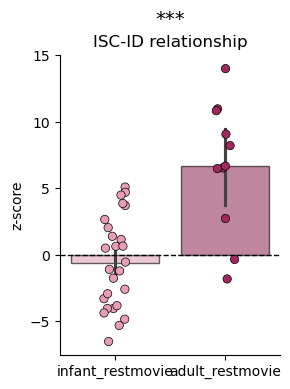

In [ ]:
# INPUT: compiled/results/combined_corr_analyses.csv (see REPRODUCIBILITY.md)
corrs = pd.read_csv('compiled/results/combined_corr_analyses.csv', index_col=0)
corrs = corrs[corrs['dataset'].isin(['infant_restmovie', 'adult_restmovie'])].reset_index()

fig, ax = plt.subplots(figsize=(3, 4))
sns.barplot(x='dataset', y='zscore', data=corrs, order=['infant_restmovie', 'adult_restmovie'], ax=ax,
            palette=[helper.dataset_colors('infant_restmovie'), helper.dataset_colors('adult_restmovie')],
            edgecolor='k', linewidth=1, alpha=0.6)
sns.stripplot(x='dataset', y='zscore', data=corrs, jitter=True, order=['infant_restmovie', 'adult_restmovie'], ax=ax,
              palette=[helper.dataset_colors('infant_restmovie'), helper.dataset_colors('adult_restmovie')],
              size=6, edgecolor='k', linewidth=0.5, alpha=1)
for sub in corrs['subject'].unique():
    sub_data = corrs[corrs['subject'] == sub].sort_values('dataset')
    if len(sub_data) == 2:
        ax.plot([0, 1], sub_data['zscore'].values, color='gray', alpha=1, linewidth=0.5, zorder=1)

infant_zscores = corrs[corrs['dataset'] == 'infant_restmovie']['zscore']
adult_zscores = corrs[corrs['dataset'] == 'adult_restmovie']['zscore']
t_stat, p_value = ttest_ind(infant_zscores, adult_zscores, equal_var=False)
print(f'T-test results: t-statistic = {t_stat:.3f}, p-value = {p_value:.3f}')
t_stat_inf, p_value_inf = ttest_rel(infant_zscores, np.zeros_like(infant_zscores))
t_stat_adult, p_value_adult = ttest_rel(adult_zscores, np.zeros_like(adult_zscores))
mi = np.mean(infant_zscores); ma = np.mean(adult_zscores)
print(f'Infant group vs 0: mean={mi:.3f}, t-statistic = {t_stat_inf:.3f}, p-value = {p_value_inf:.3f}')
print(f'Adult group vs 0: mean={ma:.3f},  t-statistic = {t_stat_adult:.3f}, p-value = {p_value_adult:.3f}')
if p_value < 0.05:
    ax.text(0.5, 17, helper.get_asterisks_pvalue(p_value),
             ha='center', va='bottom', fontsize=14)

ax.axhline(0, color='k', linestyle='--', linewidth=1)
ax.set_xlabel(''); ax.set_ylabel('z-score'); ax.set_title('ISC-ID relationship', fontsize=12)
sns.despine(); plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/isc_id_corr_zscore_comparison_infants_adults.pdf', format='pdf', transparent=True)
plt.show()

## Mean IDE: infant vs adult vs HBN, by task

In [5]:
# INPUT: compiled/info/combined_participant_info.csv -- NOTE: removed from this
# repo (participant privacy); see REPRODUCIBILITY.md to supply your own copy.
par_df = pd.read_csv('compiled/info/combined_participant_info.csv')
arm = par_df[par_df['dataset'] == 'AdultRestMovie']
a_movie_fd = arm['movie_FD'].values[:-1]
a_rest_fd = arm['rest_FD'].values[:-1]
a_sex = arm['sex'].values[:-1]
irm = par_df[par_df['dataset'] == 'InfantRestMovie']
i_movie_fd = [i for i in irm['movie_FD'].values if i != 0]
i_rest_fd = [i for i in irm['rest_FD'].values if i != 0]
i_sex = irm['sex'].values

In [6]:
# INPUT: adult_restmovie/results/*_all_subjects_results.nii.gz, adult_restmovie/masks/*
# INPUT: infant_restmovie/results/*_all_subjects_results.nii.gz, infant_restmovie/masks/*
# (see 02_infant_restmovie.ipynb / 03_adult_restmovie.ipynb for provenance of these files)
measure = 'TPHATE_DiffOp_IDE'
results_dir_arm = './adult_restmovie/results'
adult_aero_fn = f'{results_dir_arm}/aeronaut_{measure}_all_subjects_results.nii.gz'
adult_rest_fn = f'{results_dir_arm}/rest_{measure}_all_subjects_results.nii.gz'
adult_mask = NiftiMasker(mask_img='adult_restmovie/masks/adult_restmovie_intersect_mask.nii.gz').fit()
adult_aero = adult_mask.transform(adult_aero_fn).mean(axis=1)
adult_rest = adult_mask.transform(adult_rest_fn).mean(axis=1)
print(f"Loaded adult data: {adult_aero.shape[0]} subjects, {adult_rest.shape[0]} subjects")

results_dir_inf = 'infant_restmovie/results'
inf_aero_fn = f'{results_dir_inf}/aeronaut_{measure}_all_subjects_results.nii.gz'
inf_aero_mask = NiftiMasker(mask_img='infant_restmovie/masks/InfantRestMovie_intersect_mask_aeronaut.nii.gz').fit()
inf_aero = inf_aero_mask.transform(inf_aero_fn).mean(axis=1)
inf_sleep_fn = f'{results_dir_inf}/sleep_{measure}_all_subjects_results.nii.gz'
inf_sleep_mask = NiftiMasker(mask_img='infant_restmovie/masks/InfantRestMovie_intersect_mask_sleep.nii.gz').fit()
inf_sleep = inf_sleep_mask.transform(inf_sleep_fn).mean(axis=1)
print(f"Loaded infant data: {inf_aero.shape[0]} subjects, {inf_sleep.shape[0]} subjects")

subject_means = pd.DataFrame({
    'dataset': ['infant_restmovie'] * (len(inf_aero) + len(inf_sleep)) + ['adult_restmovie'] * (len(adult_aero) + len(adult_rest)),
    'task': ['aeronaut'] * len(inf_aero) + ['rest'] * len(inf_sleep) + ['aeronaut'] * len(adult_aero) + ['rest'] * len(adult_rest),
    'subject_id': list(range(len(inf_aero))) + list(range(len(inf_aero), len(inf_sleep) + len(inf_aero))) + list(range(len(adult_aero))) + list(range(len(adult_rest))),
    'FD': np.concatenate([i_movie_fd, i_rest_fd, a_movie_fd, a_rest_fd]),
    'sex': np.concatenate([i_sex, a_sex, a_sex]),
    'score': np.concatenate([inf_aero, inf_sleep, adult_aero, adult_rest])
})

Loaded adult data: 11 subjects, 11 subjects
Loaded infant data: 26 subjects, 20 subjects


In [7]:
# Adult: paired t-test (same subjects did both movie and rest)
print(ttest_rel(adult_rest, adult_aero, alternative='two-sided'))

TtestResult(statistic=3.110373265362985, pvalue=0.011053651795948184, df=10)


In [8]:
# Infant: independent t-test (different subjects did sleep vs. aeronaut)
print(ttest_ind(inf_aero, inf_sleep, alternative='two-sided', equal_var=False))

TtestResult(statistic=-3.9833535733330607, pvalue=0.00037068192715785444, df=31.75546810204107)


In [ ]:
# adult/infant: independent t-test 
print(ttest_ind(inf_aero, adult_aero, alternative='two-sided', equal_var=False))

TtestResult(statistic=-2.2715477143508744, pvalue=0.034772202949004904, df=19.239491550205013)


## Composite bar chart: Infant / Adult / HBN mean IDE by task (and HBN age bin)

In [11]:
# INPUT: compiled/results/hbn_compiled_results.csv (see REPRODUCIBILITY.md)
# Rebuilds the HBN per-subject-x-task-x-agebin table (see 05_hbn.ipynb "ANOVA" cell for the
# canonical version); reproduced here so this notebook is self-contained.
hbn_results = pd.read_csv('compiled/results/hbn_compiled_results.csv')
hbn_results = hbn_results[hbn_results['measure'] == 'TPHATE_DiffOp_IDE']
temp_hbn = hbn_results.groupby(['subject_id', 'task', 'age_months', '_age_raw']).mean(numeric_only=True).reset_index()
Q = 6
bin_edges = pd.qcut(temp_hbn['_age_raw'], q=Q, retbins=True)[1]
bin_labels = [f'{int(bin_edges[i])}-{int(bin_edges[i+1])}' for i in range(len(bin_edges) - 1)]
temp_hbn['AgeGroup_Binned'] = pd.qcut(temp_hbn['_age_raw'], q=Q, retbins=False, labels=bin_labels)

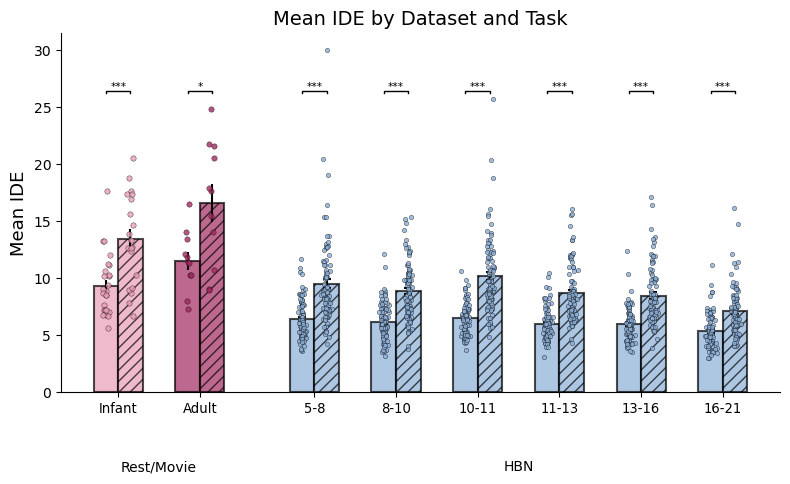

In [12]:
infant_color = helper.dataset_colors('infant_restmovie')
adult_color = helper.dataset_colors('adult_restmovie')
hbn_color = helper.dataset_colors('hbn')

rest_keywords = {'rest', 'sleep'}
def is_rest_task(task):
    return any(k in task.lower() for k in rest_keywords)

def sig_label(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'n.s.'

def add_bracket(ax, x1, x2, y, label, tick_h=0.15):
    ax.plot([x1, x1, x2, x2], [y, y + tick_h, y + tick_h, y], lw=1.0, c='k', clip_on=False)
    ax.text((x1 + x2) / 2, y + tick_h + 0.02, label, ha='center', va='bottom', fontsize=7.5, clip_on=False)

datasets = ['infant_restmovie', 'adult_restmovie']
ds_colors = {'infant_restmovie': infant_color, 'adult_restmovie': adult_color}
tasks_by_ds = {ds: sorted(subject_means[subject_means['dataset'] == ds]['task'].unique(),
                           key=lambda t: (1 if is_rest_task(t) else 0, t)) for ds in datasets}

hbn_means = temp_hbn
hbn_tasks = sorted(hbn_means['task'].unique(), key=lambda t: (1 if is_rest_task(t) else 0, t))
order_hbn = ['5-8', '8-10', '10-11', '11-13', '13-16', '16-21']
bar_width = 0.3
gap = 0.4
hbn_x_start = len(datasets) + gap
hbn_x_centers = [hbn_x_start + j for j in range(len(order_hbn))]

fig, ax = plt.subplots(figsize=(8, 5))

group_bars = {}
for i, ds in enumerate(datasets):
    tasks = tasks_by_ds[ds]
    n = len(tasks)
    offsets = np.linspace(-(n - 1) * bar_width / 2, (n - 1) * bar_width / 2, n)
    color = ds_colors[ds]
    group_bars[ds] = {}
    for task, offset in zip(tasks, offsets):
        pos = i + offset
        df_t = subject_means[(subject_means['dataset'] == ds) & (subject_means['task'] == task)]
        mean_v = df_t['score'].mean(); sem_v = df_t['score'].sem()
        hatch = '///' if is_rest_task(task) else None
        ax.bar(pos, mean_v, width=bar_width, color=color, hatch=hatch,
               edgecolor='k', linewidth=1.5, alpha=0.7,
               yerr=sem_v, capsize=0, error_kw={'elinewidth': 1.5, 'capthick': 1.5})
        jitter = np.random.normal(0, bar_width * 0.08, len(df_t))
        ax.scatter(pos + jitter, df_t['score'], color=color, s=15, alpha=0.8, edgecolors='k', linewidth=0.3, zorder=5)
        group_bars[ds][task] = dict(pos=pos, mean=mean_v, sem=sem_v, scores=df_t['score'].values)

for ds in datasets:
    info = group_bars[ds]
    movie = next((t for t in info if not is_rest_task(t)), None)
    rest = next((t for t in info if is_rest_task(t)), None)
    if not movie or not rest:
        continue
    s_m, s_r = info[movie]['scores'], info[rest]['scores']
    if ds == 'infant_restmovie':
        _, pval = ttest_ind(s_m, s_r)
    else:
        n = min(len(s_m), len(s_r))
        _, pval = ttest_rel(s_m[:n], s_r[:n])
    y_top = 26
    add_bracket(ax, info[movie]['pos'], info[rest]['pos'], y_top + 0.2, sig_label(pval))

hbn_bin_info = []
for j, ag in enumerate(order_hbn):
    df_ag = hbn_means[hbn_means['AgeGroup_Binned'] == ag]
    n = len(hbn_tasks)
    offsets = np.linspace(-(n - 1) * bar_width / 2, (n - 1) * bar_width / 2, n)
    bin_data = {}
    for task, offset in zip(hbn_tasks, offsets):
        df_t = df_ag[df_ag['task'] == task]
        if df_t.empty:
            continue
        pos = hbn_x_centers[j] + offset
        mean_v = df_t['score'].mean(); sem_v = df_t['score'].sem()
        hatch = '///' if is_rest_task(task) else None
        ax.bar(pos, mean_v, width=bar_width, color=hbn_color, hatch=hatch,
               edgecolor='k', linewidth=1.5, alpha=0.7,
               yerr=sem_v, capsize=3, error_kw={'elinewidth': 1.5, 'capthick': 1.5})
        jitter = np.random.normal(0, bar_width * 0.08, len(df_t))
        ax.scatter(pos + jitter, df_t['score'], color=hbn_color, s=10, alpha=0.8, edgecolors='k', linewidth=0.3, zorder=5)
        bin_data[task] = dict(pos=pos, mean=mean_v, sem=sem_v, scores=df_t.set_index('subject_id')['score'])

    movie_t = next((t for t in bin_data if not is_rest_task(t)), None)
    rest_t = next((t for t in bin_data if is_rest_task(t)), None)
    if movie_t and rest_t:
        common = bin_data[movie_t]['scores'].index.intersection(bin_data[rest_t]['scores'].index)
        if len(common) >= 5:
            _, pval = ttest_rel(bin_data[movie_t]['scores'][common], bin_data[rest_t]['scores'][common])
            y_top = 26
            add_bracket(ax, bin_data[movie_t]['pos'], bin_data[rest_t]['pos'], y_top + 0.2, sig_label(pval))
        hbn_bin_info.append(dict(x=hbn_x_centers[j], movie=bin_data[movie_t]['mean'], rest=bin_data[rest_t]['mean']))

ax.set_xticks(list(range(len(datasets))) + hbn_x_centers)
ax.set_xticklabels(['Infant', 'Adult'] + order_hbn, fontsize=9.5)
ax.set_ylabel('Mean IDE', fontsize=13)
ax.set_title('Mean IDE by Dataset and Task', fontsize=14)

ylim = ax.get_ylim()
y_sec = ylim[0] - (ylim[1] - ylim[0]) * 0.22
ax.text(0.5, y_sec, 'Rest/Movie', ha='center', clip_on=False)
ax.text(hbn_x_start + (len(order_hbn) - 1) / 2, y_sec, 'HBN', ha='center', clip_on=False)

sns.despine(); plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/infant_adult_hbn_rest_movie_ide_comparison.pdf', format='pdf', transparent=True)
plt.show()